# A Quantum Algorithm for Solving Linear Differential Equations
This notebook follows the paper (https://arxiv.org/pdf/1807.04553).
## Problem
An unknown vector $ψ(t)$ starts from an initial point $ψ(0)$ and follows an evolution described by the linear differential equation:

$$
\frac{d|ψ(t)⟩}{dt} = -iH |ψ(t)⟩
$$

where:  

- $H$ is an Hamiltonian H = α(X ⊗ I) + β(Z ⊗ Z) 
- Initial State (t=0): |ψ(0)⟩ = |01⟩
- Parameters: α = 1.0, β = 0.5, ℏ = 1, t = 1.0.
- $|ψ(t)⟩$ is an 2-dimensional vector

This maps to LDE given in paper as
$$
\frac{dx(t)}{dt} = M x(t) + b
$$

where:  

- $M$ is an arbitrary $N \times N$ matrix  
- $b$ is an $N$-dimensional vector  
- $x(t)$ is an $N$-dimensional vector

The analytical solution of the equation can be written as:

$$
x(t) = e^{Mt} x(0) + (e^{Mt} - I) M^{-1} b.
$$

If the exponential evolution $e^{Mt}$ and the inverse operator $M^{-1}$ can be effectively realized, one can easily obtain the solution $x(t)$. In the following, we present the basic idea of finding $x(t)$ based on a quantum algorithm. By Taylor expansion, the solution $x(t)$ is approximately:

$$
x(t) \approx \sum_{m=0}^{k} \frac{(M t)^m}{m!} x(0) + \sum_{n=1}^{k} \frac{M^{n-1} t^n}{n!} b, 
$$

where $k$ is the approximation order of taylor expansion and other terms can be considered as Truncation error.

 -But here in out question M = -iH and b=0

Hence, the k-th order approximate solution converts to 
 
$$
|ψ(t)\rangle \approx \sum_{m=0}^{k} \frac{\|ψ(0)\| (\|-iH\| A t)^m}{m!} |ψ(0)\rangle 
$$



- To obtain the solution, we need to add the an ancilla register of log2 k qubits.

 - A is given by  $$ A = \frac {-iH}{\|H\|}$$ and H = α(X ⊗ I) + β(Z ⊗ Z) so, $$ A = \frac {-iα }{\|H\|} (X ⊗ I) + \frac {-iβ }{\|H\|} (Z ⊗ Z) $$ since (X ⊗ I) and (Z ⊗ Z) are unitary, basically $$ A = α1 * A1 + α2 * A2 $$ Since here A is unitary We will follow the method mentioned in first part of Unitary evolution
 - REMARK ** The H itself is non unitary but A , which is equal to turns out to be $$ A = \frac {-iH}{\|H\|}$$ unitary.



In [7]:
import numpy as np, math
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import UnitaryGate

# 1) Define problem parameters and Hamiltonian H
alpha = 1.0
beta = 0.5
t = 1.0

# Pauli matrices and identity
X = np.array([[0,1],[1,0]], dtype=complex)
Z = np.array([[1,0],[0,-1]], dtype=complex)
I2 = np.eye(2, dtype=complex)

# Hamiltonian H = alpha*(X⊗I) + beta*(Z⊗Z)
H = alpha * np.kron(X, I2) + beta * np.kron(Z, Z)
assert np.allclose(H, H.conj().T)  # Check H is Hermitian

# Spectral norm of H
norm_H = np.linalg.norm(H, 2)

# Define unitary A = -i * H / ||H||
A = -1j * H / norm_H
# Precompute powers A^k for k=0..4
A_powers = [np.linalg.matrix_power(A, k) for k in range(5)]

# Analytic solution: psi_exact = exp(-i H t) |psi(0)> #################Using classical methods
# Initial state |psi(0)> = |01> (in 2-qubit basis [00,01,10,11])
psi0 = np.array([0, 1, 0, 0], dtype=complex)
omega = norm_H
# Using matrix exponential via power series: U = cos(omega t) I + (-i sin(omega t)/omega) H
U_exact = np.cos(omega*t) * np.eye(4) + (-1j * np.sin(omega*t) / omega) * H
psi_exact = U_exact.dot(psi0)  # 4-component statevector


## Since A is Unitary 

Since operator $A$ is unitary, the powers of $A$ will also be unitary. Let:

- $U_m = A^m$,  
- $U_n = A^n$,  
- $C_m = \frac{\|x(0)\| (\|M\| t)^m}{m!}$,  
- $D_n = \frac{\|b\| (\|M\| t)^{n-1} t}{n!}$.  

By substituting them into Eq. $(1)$, 

$$
|x(t)\rangle \approx \frac{1}{N_2} \left( \sum_{m=0}^{k} C_m U_m |x(0)\rangle + \sum_{n=1}^{k} D_n U_{n-1} |b\rangle \right)
$$

where $N^2 = C^2 + D^2$ with:

$$
C = \sqrt{\sum C_m}, \quad D = \sqrt{\sum D_n}
$$

as the normalization factor. Thus, the $j$-th element of $x(t)$ would be:

$$
x_j (t) = N^2 \langle j | x(t) \rangle.
$$

 - Remark We do not need D as homogeneous and here, N = C

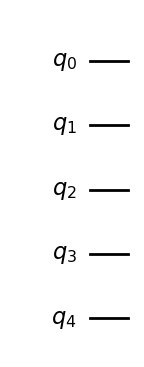

In [8]:
n_system = 2
n_power = 3   # To represent k=0 to 4  for 4th order taylor truncation 
qc = QuantumCircuit(n_power + n_system)
power_qs  = list(range(n_power))                 # ancilla qubits |k>
system_qs = list(range(n_power, n_power+n_system)) 
qc.draw("mpl")

### (i) Encoding

The first operator $V$ is defined as:

$$
V = \frac{1}{N}
\begin{bmatrix}
C & D \\
D & -C
\end{bmatrix}.
$$

This operation puts the first ancilla qubit into superposition but Since D=0 and C = N , here V = Z which is not needed.
 - ***WE donot need to use extra ancilla qubit here as its a homogeneous case


the ancilla register $|0\rangle^{⊗T}$, where $T = log_{2}(k+1)$, and the input register $|𝜙\rangle$ are evolved as:

$$
|0\rangle \sum_{m=0}^{k} \sqrt{C_m} |m\rangle
$$

 - and $$ |x(0)\rangle.$$

After computation, the system evolves into:

$$
|\psi_1\rangle = \frac{1}{N}
\left(  \sum_{m=0}^{k} \sqrt{C_m} |m\rangle |x(0)\rangle  \right).

$$

### Calculating Matrix $ V_{S1} $

$$
V_{S1} = \frac{1}{C}
\begin{bmatrix}
\sqrt{C_0} & Q & Q & Q & Q & Q \\
\sqrt{C_1} & Q & Q & Q & Q & Q \\
\vdots & Q & Q & Q & Q & Q \\
\sqrt{C_k} & Q & Q & Q & Q & Q
\end{bmatrix}_{(k+1) \times (k+1)}
$$

Where $Q$ s are arbitary values that make the matrix Unitary 

[0.5734391893360206, 0.6063381201345609, 0.4533434844755908, 0.27675422156081364, 0.14631598045713365, 0.0, 0.0, 0.0]
[[ 5.73439189e-01+0.j  8.19248129e-01+0.j -8.25469260e-17+0.j
  -1.86165265e-16+0.j -4.14805008e-16+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j]
 [ 6.06338120e-01+0.j -4.24411150e-01+0.j  6.72479933e-01+0.j
  -9.76920403e-17+0.j -3.89591408e-16+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j]
 [ 4.53343484e-01+0.j -3.17321348e-01+0.j -6.09020633e-01+0.j
   5.68225938e-01+0.j -5.93846660e-16+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j]
 [ 2.76754222e-01+0.j -1.93716300e-01+0.j -3.71791008e-01+0.j
  -7.27463158e-01+0.j  4.67386238e-01+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j]
 [ 1.46315980e-01+0.j -1.02415025e-01+0.j -1.96560564e-01+0.j
  -3.84599319e-01+0.j -8.84053225e-01+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j]
 [ 0.00000000e+00+0.j  0.00000000e+00+0.j  0.00

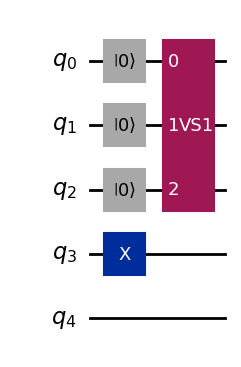

In [9]:
qc.x(system_qs[0]) # We initiallised the state to |01>

# then for calculating Vs1
C = [ (omega*t)**m / math.factorial(m) for m in range(5) ]  # C0 to C4
# First column amplitudes ~ sqrt(C_k)
first_col = [math.sqrt(C[m]) for m in range(5)]
# Pad with zeros for remaining 3 states (since 3 ancilla qubits -> 8 basis states)
first_col += [0.0] * (2**n_power - len(first_col))
# Normalize the first column
col_norm = math.sqrt(sum(abs(v)**2 for v in first_col))
first_col = [v/col_norm for v in first_col]

# Construct an 8x8 unitary VS1: set first column and complete via Gram-Schmidt
VS1 = np.zeros((2**n_power, 2**n_power), dtype=complex)
VS1[:,0] = np.array(first_col, dtype=complex)
col = 1
for i in range(2**n_power):
    vec = np.zeros(2**n_power, complex)
    vec[i] = 1.0
    for j in range(col):
        proj = np.vdot(VS1[:,j], vec)
        vec -= proj * VS1[:,j]
    norm_vec = np.linalg.norm(vec)
    if norm_vec < 1e-8:
        continue
    VS1[:,col] = vec / norm_vec
    col += 1
    if col == 2**n_power:
        break
qc.reset(power_qs)
print(first_col)
print(VS1)
VS1_gate = UnitaryGate(VS1, label="VS1")
qc.append(VS1_gate, power_qs)

print(np.allclose(VS1.conj().T @ VS1, np.eye(8)))
qc.draw('mpl')

### Entanglement Creation

The unitary matrix $ U_m $ is conditionally applied depending on the value in `ancilla` register 

The resulting state is,

$$
|\psi_2\rangle = \frac{1}{C}
\left(  \sum_{m=0}^{k} \sqrt{C_m} |m\rangle U_m |x(0)\rangle\right).
$$


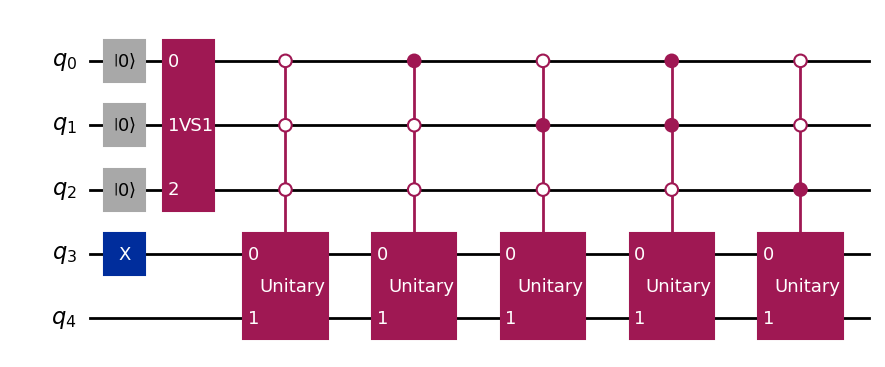

In [10]:
# Apply controlled-A^k: For each k=1 to 4, apply A^k controlled on ancilla=|k>
# (We implement this by bit-flipping ancilla states then a multi-control gate

for k in range(0, 5):
    bits = format(k, f'0{n_power}b')  # e.g., '010' for k=2
    ctrl_state = int(bits, 2)         # convert '010' → 2
    Uk = UnitaryGate(A_powers[k])
    
    # Controlled on power_qs being in |bits⟩ exactly
    Uk_ctrl = Uk.control(num_ctrl_qubits=n_power, ctrl_state=ctrl_state)
    qc.append(Uk_ctrl, power_qs[:] + system_qs[:])
  

qc.draw('mpl')

###  Decoding

The steps applied in Encoding are reversibly applied.
$$
|\psi_3\rangle = \frac{1}{C}  |0\rangle^{\otimes 3} 
\left(\sum_{m=0}^{k} C_mU_m |x(0)\rangle\right).
$$

Qiskit final state (system qubits q3,q4):
|00⟩: (-0-0j)
|01⟩: (0.446405-0.63948j)
|10⟩: (-0+0j)
|11⟩: (-0.89281+1.27896j)


/tmp/ipykernel_279390/233489450.py:17: DeprecationWarning: The return type of saved statevectors has been changed from a `numpy.ndarray` to a `qiskit.quantum_info.Statevector` as of qiskit-aer 0.10. Accessing numpy array attributes is deprecated and will result in an error in a future release. To continue using saved result objects as arrays you can explicitly cast them using  `np.asarray(object)`.
  for i, amp in enumerate(full_sv):


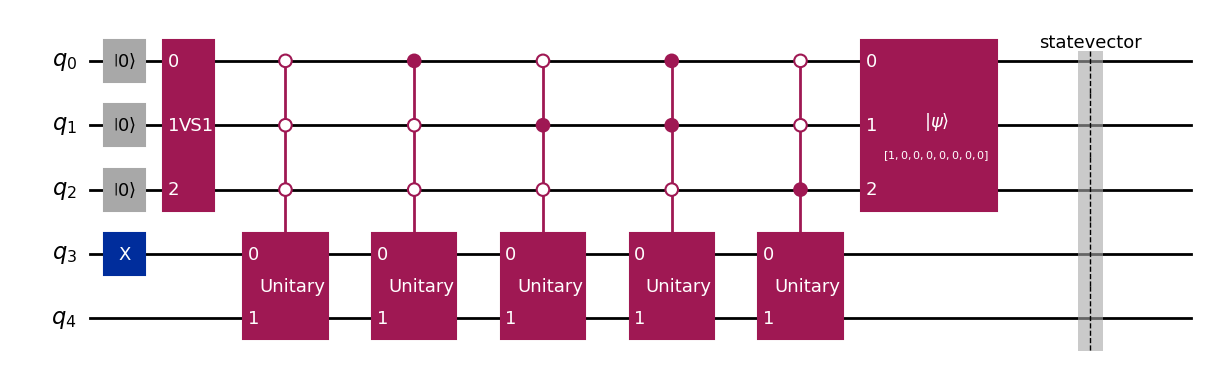

In [11]:
qc.initialize([1] + [0]*(2**n_power - 1), power_qs)

sim = AerSimulator(method='statevector')
tc = transpile(qc, sim)
qc.save_statevector()

# Simulate and get result
sim = AerSimulator(method='statevector')
tc = transpile(qc, sim)
result = sim.run(tc).result()

# Get the saved statevector from result.data()
full_sv = result.data(0)['statevector']
# print(full_sv)
psi_qc = []

for i, amp in enumerate(full_sv):
    bits = format(i, '05b')[::-1]  # reversed because Qiskit uses little-endian (q0 is LSB)

    # Check if ancilla (q0, q1, q2) = |000⟩
    if bits[0] == '0' and bits[1] == '0' and bits[2] == '0':
        psi_qc.append(amp)

psi_qc = np.array(psi_qc)

psi_nqc= col_norm*psi_qc

# Print the resulting 2-qubit system state
print("Qiskit final state (system qubits q3,q4):")
for i, amp in enumerate(psi_nqc):
    label = format(i, '02b')
    print(f"|{label}⟩: {np.round(amp, 6)}")

qc.draw('mpl')

## Comparision

In [12]:

# Compare to analytic result
fidelity = abs(np.vdot(psi_exact, psi_qc))**2

# print("Qiskit final state (system qubits):", np.round(psi_qc, 6))
print("Analytical target state:        ", np.round(psi_exact, 6))

print("Fidelity = {:.6f}".format(fidelity))


Analytical target state:         [0.      +0.j       0.437451+0.402153j 0.      +0.j
 0.      -0.804307j]
Fidelity = 0.846909
